<a href="https://colab.research.google.com/github/alfaiznaiemkhan/Ames-house-price-prediction-linear-regression-/blob/main/House_price_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import liberary and load data
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew, norm
from sklearn.preprocessing import RobustScaler
df = pd.read_csv('train.csv')

In [ ]:
# Seen Top of the data
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Shape of data
print('Shape :',df.shape)

Shape : (1460, 81)


In [ ]:
# Info of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Mathematical representation of each numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
# Finding the null values in all numerical columns
df.isnull().mean().sort_values(ascending=False).head(25) * 100

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


# Split Target - Features

In [ ]:
# split target
X = df.iloc[:, 0:79]
y = df.iloc[:,-1]
print('X Shape:',X.shape)
print('y Shape:',y.shape)

X Shape: (1460, 79)
y Shape: (1460,)


In [ ]:
# Target Variable
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


# Exploratery Data Analysis

Skewness : 1.8828757597682129


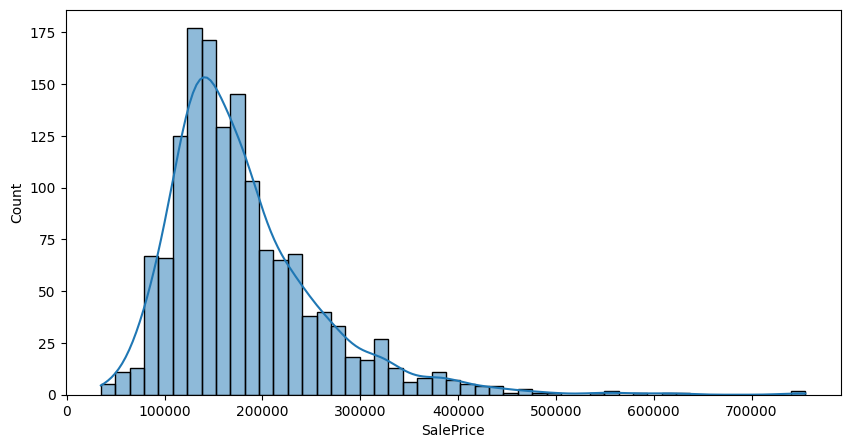

In [ ]:
# SalePrice hist representation and skewness
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'], kde=True)
plt.xlabel('SalePrice')
plt.ylabel('Count')
print('Skewness :',df['SalePrice'].skew())

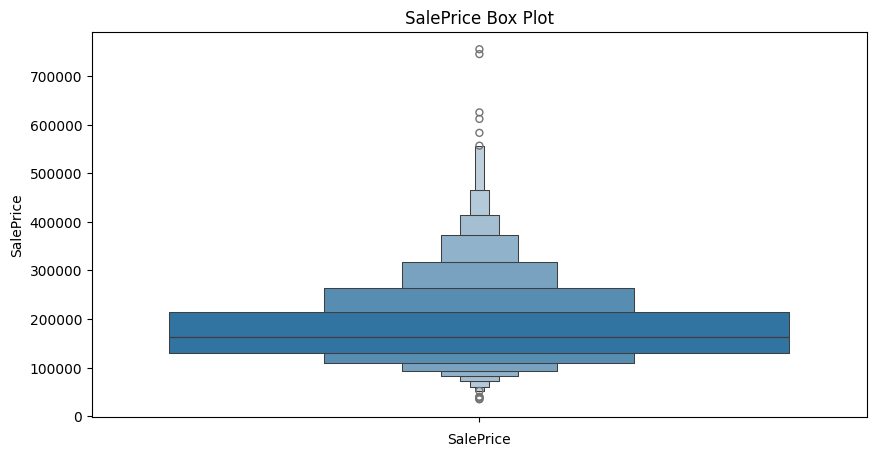

In [ ]:
# Box Plot Representation of SalePrice
plt.figure(figsize=(10,5))
sns.boxenplot(df['SalePrice'])
plt.title('SalePrice Box Plot')
plt.xlabel('SalePrice')
plt.show()

### 1. Correlation Heatmap
Let's check which numerical features are most strongly correlated with `SalePrice`.

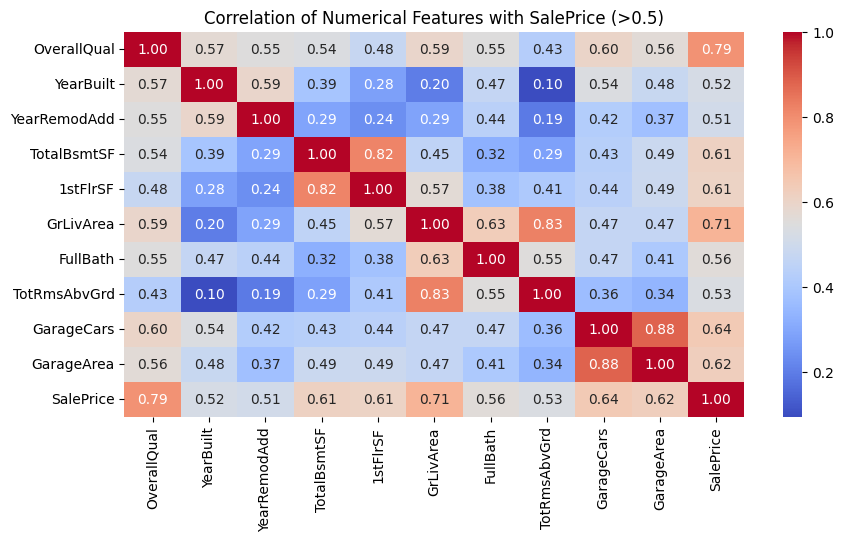

In [ ]:
plt.figure(figsize=(10, 5))
# Calculating correlation for numeric columns only
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Focusing on top correlations with SalePrice
top_corr_features = corr.index[abs(corr["SalePrice"]) > 0.5]
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Numerical Features with SalePrice (>0.5)")
plt.show()

 2. Relationship with Overall Quality
Since `OverallQual` usually has the highest correlation, let's visualize it.
 3. Living Area vs. SalePrice
Let's check for outliers in the Ground Living Area (`GrLivArea`) which is another strong predictor.

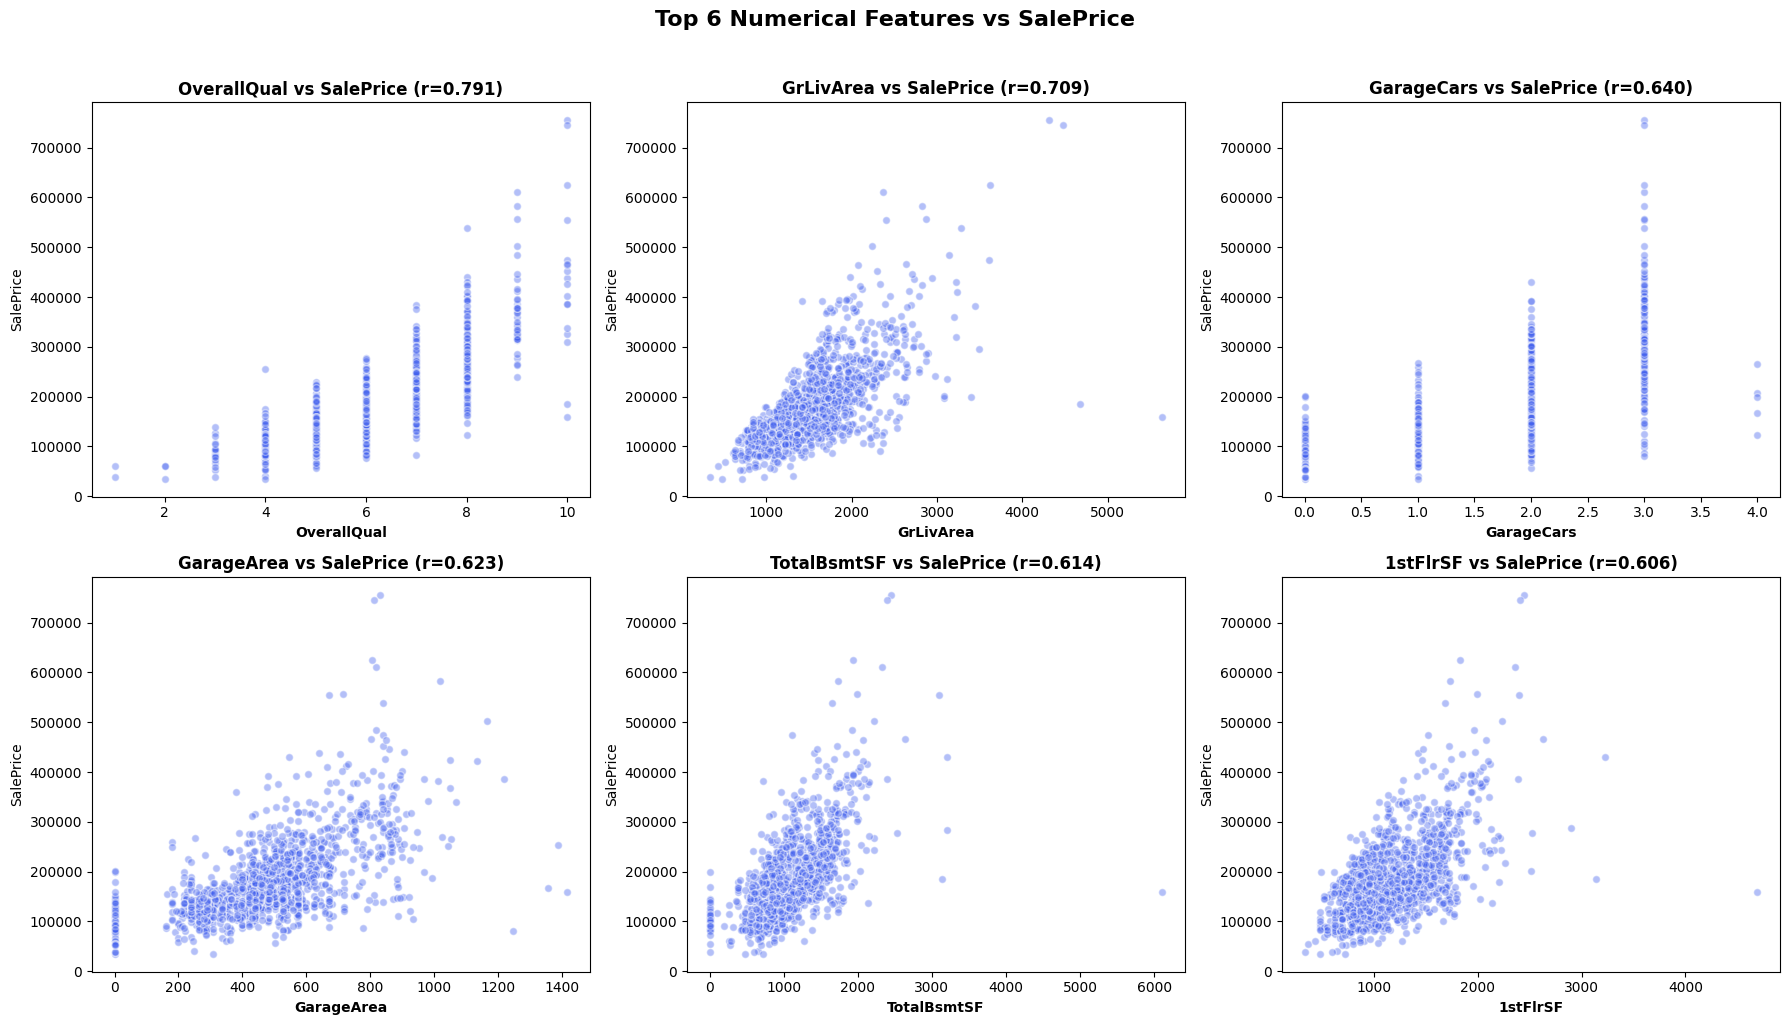

In [ ]:
# Graphical Representation of Top 6 features with SalePrice
correlations = numeric_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
top6 = correlations.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(top6):
    ax = axes[i//3, i%3]
    ax.scatter(df[feat], df['SalePrice'], alpha=0.4, c='#4361ee', edgecolor='white', s=30)
    ax.set_xlabel(feat, fontweight='bold')
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice (r={df[feat].corr(df["SalePrice"]):.3f})', fontweight='bold')
plt.suptitle('Top 6 Numerical Features vs SalePrice', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Categorical Features
categpical_features = df.select_dtypes(include=['object']).columns
print('Categorical Features :',len(categpical_features))
categpical_features

Categorical Features : 43


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
# Unique Values in each Features
df[categpical_features].nunique().sort_values()

,0
Street,2
Alley,2
Utilities,2
CentralAir,2
MasVnrType,3
LandSlope,3
PavedDrive,3
GarageFinish,3
PoolQC,3
ExterQual,4


/tmp/ipykernel_1280/2972642126.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feat, y='SalePrice', data=df, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_1280/2972642126.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feat, y='SalePrice', data=df, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_1280/2972642126.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feat, y='SalePrice', data=df, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_1280/2972642126.py:7: FutureWarning: 

Passing `palette` without assig

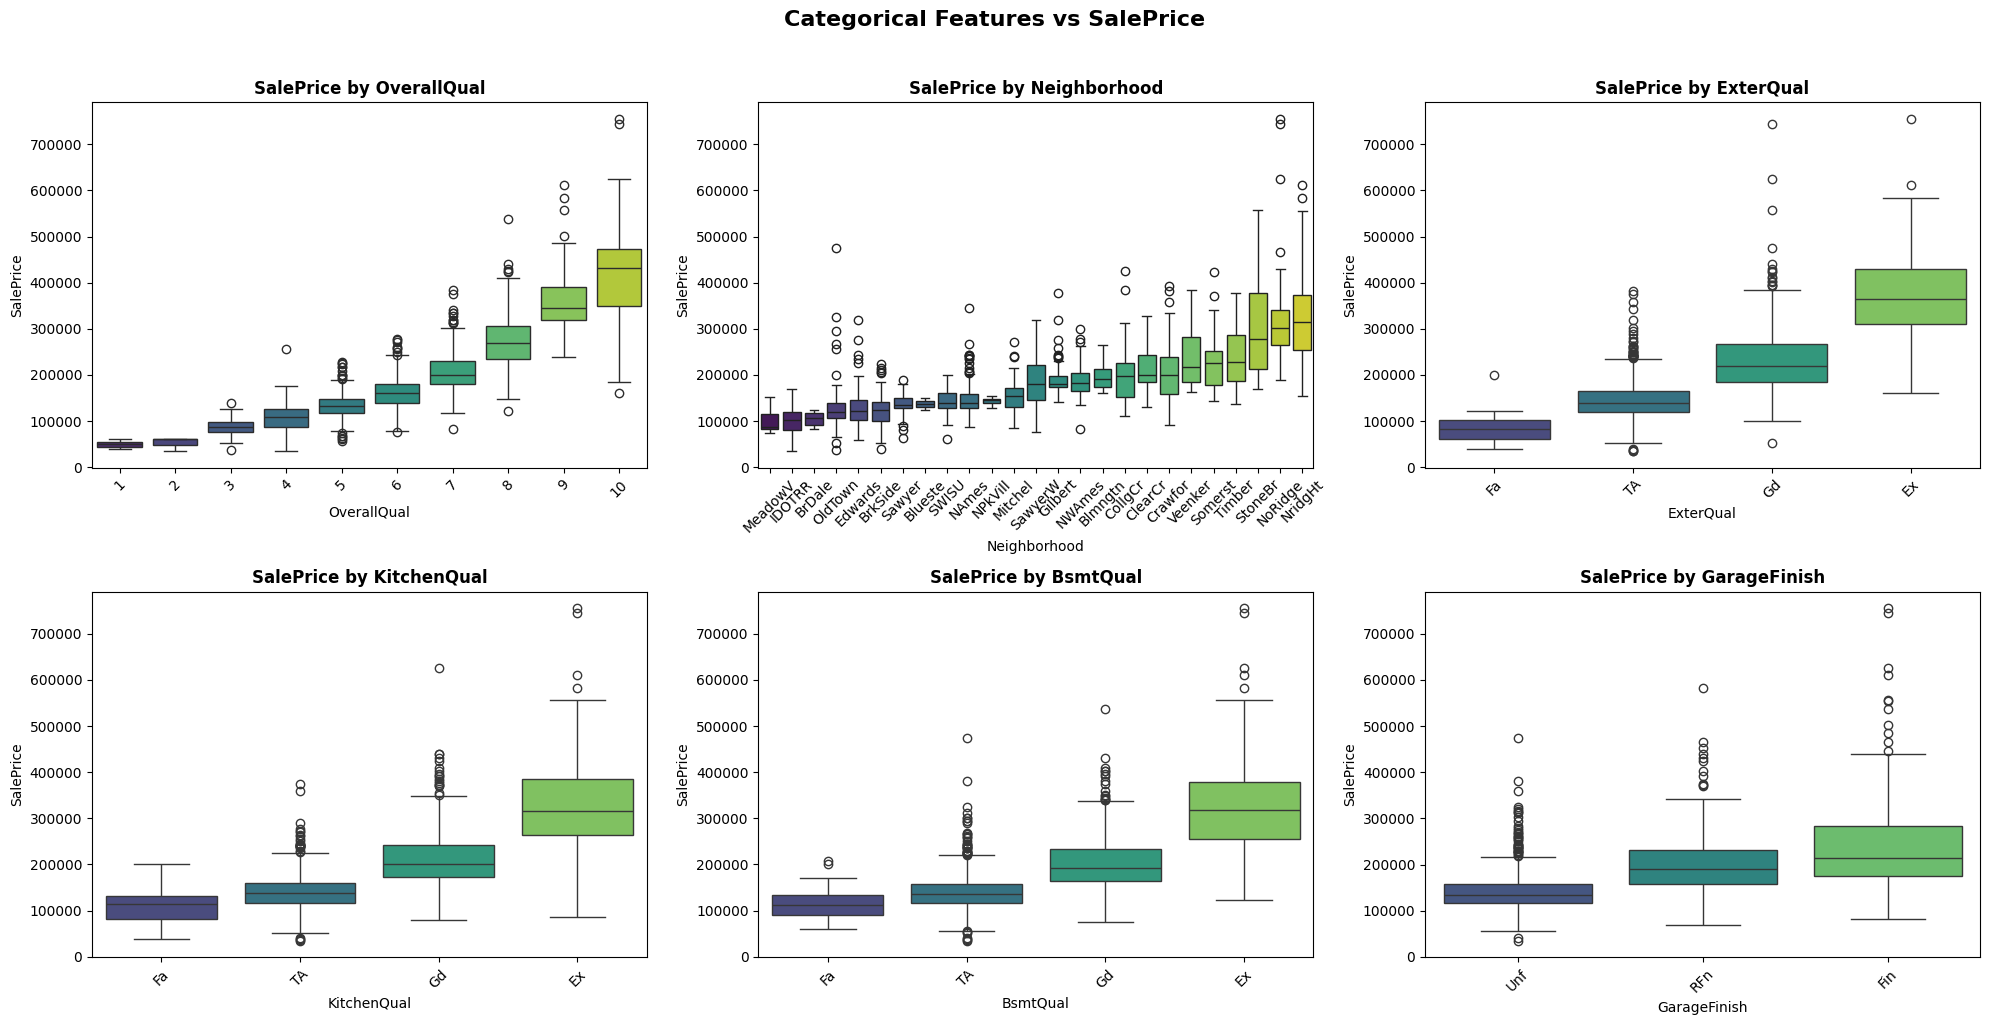

In [ ]:
# Box plots for key categorical features
cat_feats = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, feat in enumerate(cat_feats):
    ax = axes[i//3, i%3]
    order = df.groupby(feat)['SalePrice'].median().sort_values().index
    sns.boxplot(x=feat, y='SalePrice', data=df, order=order, ax=ax, palette='viridis')
    ax.set_title(f'SalePrice by {feat}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Features vs SalePrice', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1280/3323409238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, palette='coolwarm', ax=ax)


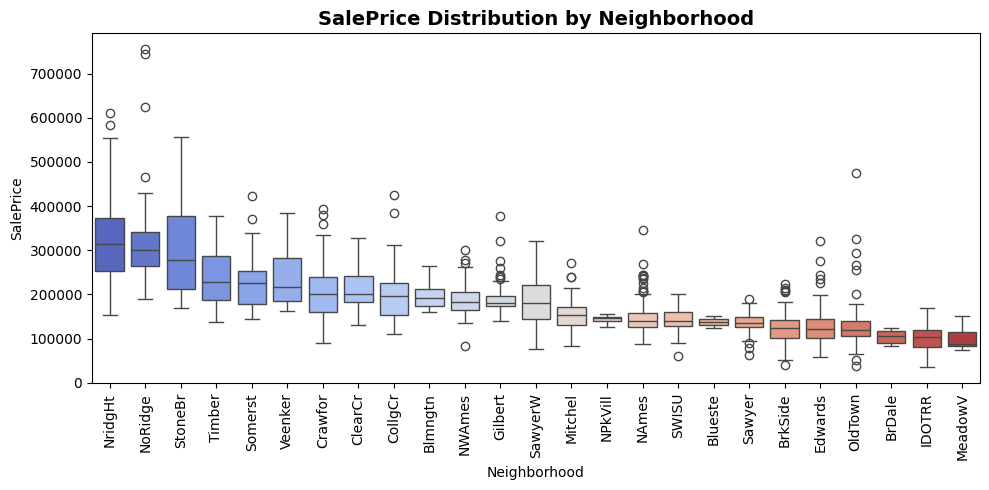

In [ ]:
# Neighborhood price distribution
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, palette='coolwarm', ax=ax)
ax.set_title('SalePrice Distribution by Neighborhood', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

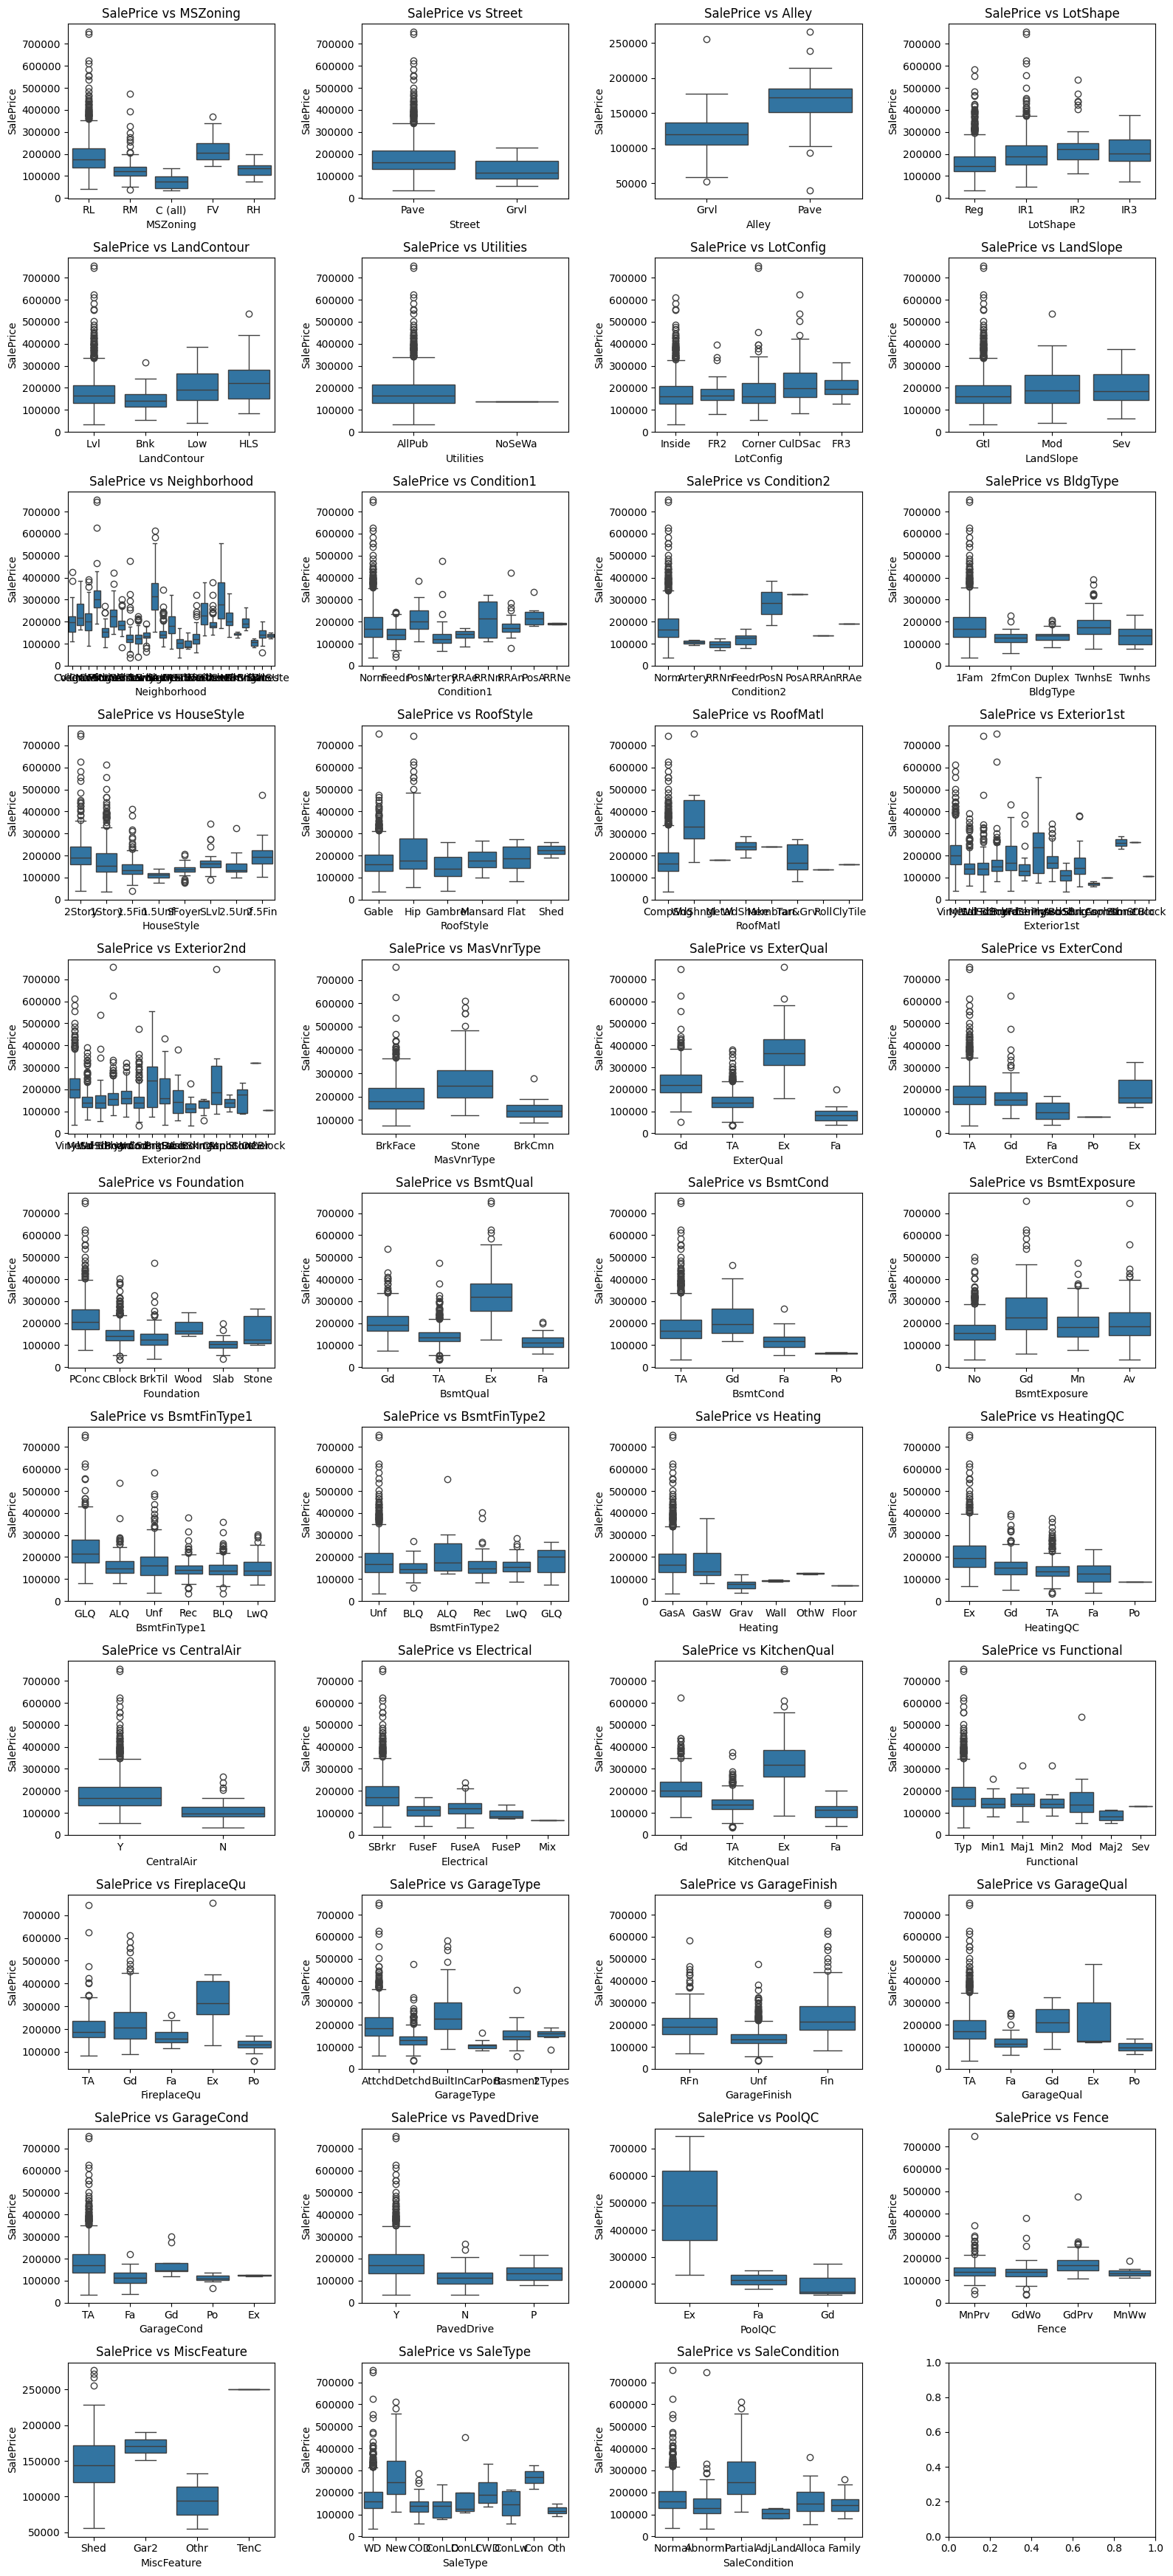

In [ ]:

# plot with SalePrice of every categorical columns
fig, axes = plt.subplots(11,4, figsize=(16, 35))
axes = axes.flatten()
for ax, col in zip(axes, categpical_features):
    sns.boxplot(x=col, y='SalePrice', data=df, ax=ax)
    ax.set_title(f'SalePrice vs {col}')
plt.tight_layout()
plt.show()

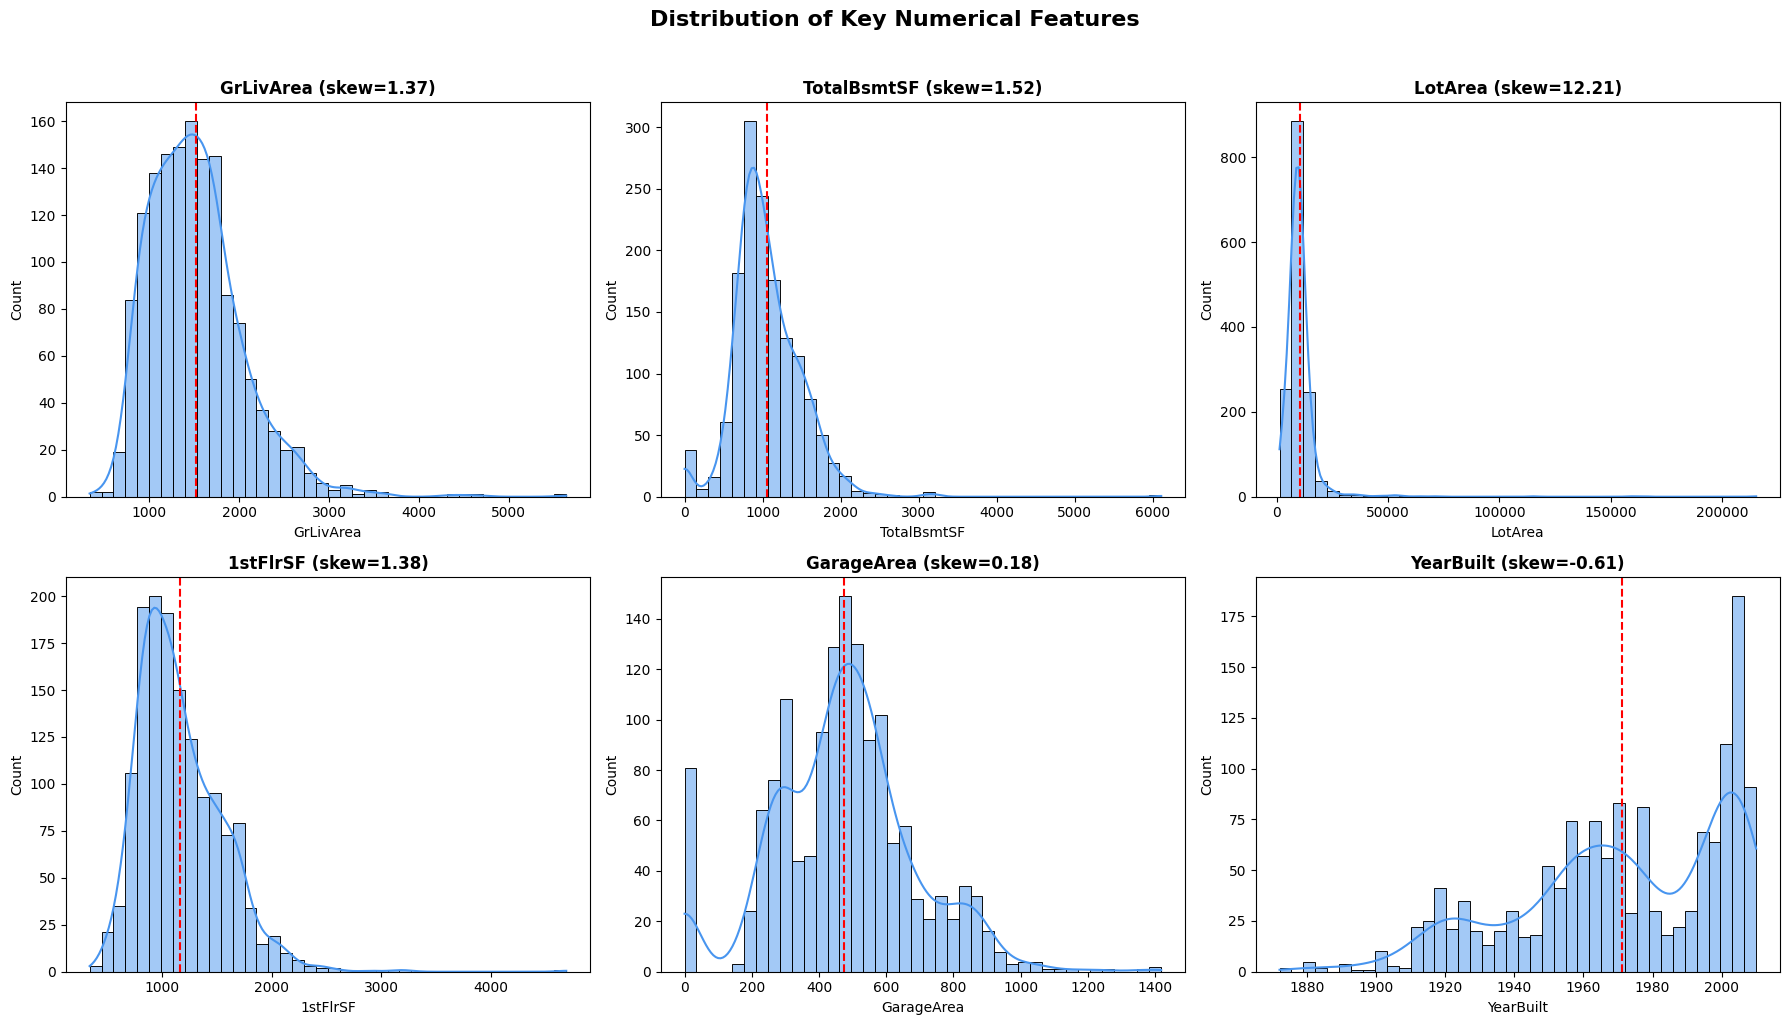

In [ ]:
# Distribution plots for key numeric features
key_nums = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF', 'GarageArea', 'YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(key_nums):
    ax = axes[i//3, i%3]
    sns.histplot(df[feat], kde=True, bins=40, color='#4895ef', ax=ax)
    ax.axvline(df[feat].mean(), color='red', ls='--', lw=1.5)
    ax.set_title(f'{feat} (skew={df[feat].skew():.2f})', fontweight='bold')
plt.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# feature with missing values
missing_col = df.isnull().sum()
missing_col = missing_col[missing_col > 0].sort_values(ascending=False)

In [ ]:
# Feature Extraction
garage_col = ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
bsmt_col = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
other_col = ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

In [ ]:
print('Null val :\n',df[garage_col].isnull().sum())
print('Null val :\n',df[bsmt_col].isnull().sum())
print('Null val :\n',df[other_col].isnull().sum())

Null val :
 GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64
Null val :
 BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
dtype: int64
Null val :
 Alley          1369
MasVnrType      872
FireplaceQu     690
PoolQC         1453
Fence          1179
MiscFeature    1406
dtype: int64


In [ ]:
# null values by the columns
df.loc[
    df['PoolQC'].isnull(),
    ['PoolQC', 'PoolArea', 'SalePrice']
].head(10)


,PoolQC,PoolArea,SalePrice
0,NaN,0,208500
1,NaN,0,181500
2,NaN,0,223500
3,NaN,0,140000
4,NaN,0,250000
5,NaN,0,143000
6,NaN,0,307000
7,NaN,0,200000
8,NaN,0,129900
9,NaN,0,118000


In [ ]:
# null values by the columns
df.loc[
    df['GarageType'].isnull(),
    ['GarageType', 'GarageCars','GarageArea', 'SalePrice']
].head(10)


,GarageType,GarageCars,GarageArea,SalePrice
39,NaN,0,0,82000
48,NaN,0,0,113000
78,NaN,0,0,136500
88,NaN,0,0,85000
89,NaN,0,0,123600
99,NaN,0,0,128950
108,NaN,0,0,115000
125,NaN,0,0,84500
127,NaN,0,0,87000
140,NaN,0,0,115000


In [ ]:
# copy of dataframe
df_clean = df.copy()

In [ ]:
# filling null columns with None & 0
none_cols = ['PoolQC','Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'FireplaceQu','MiscFeature','Fence','GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
zero_cols = ['GarageYrBlt', 'GarageCars', 'GarageArea', 'BsmtFinSF2','BsmtFinSF1','BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
df_clean[none_cols] = df_clean[none_cols].fillna('None')
df_clean[zero_cols] = df_clean[zero_cols].fillna(0)

In [ ]:
# filling values with mode & median
df_clean['Electrical'] = df_clean['Electrical'].fillna(
    df_clean['Electrical'].mode()[0]
)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(
    df_clean['LotFrontage'].median()
)

In [ ]:
# after filling values
missing_after = df_clean.isnull().mean() * 100
missing_after[missing_after > 0].sort_values(ascending=False)

,0


Text(0.5, 0, 'GrLiveArea')

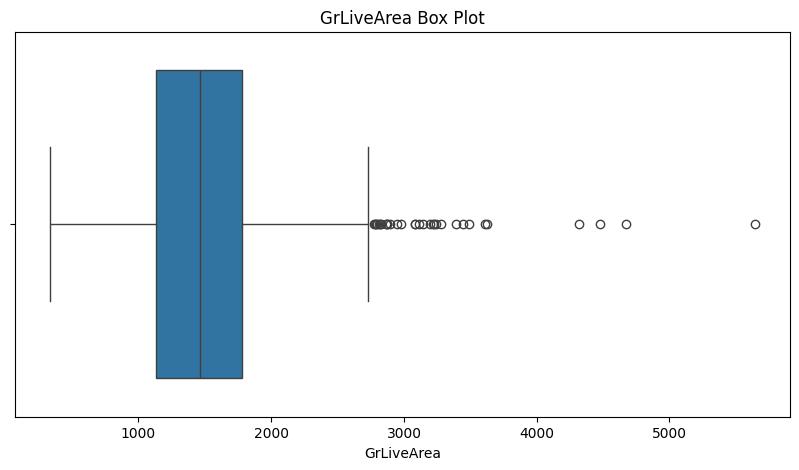

In [ ]:
# determining outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean['GrLivArea'])
plt.title('GrLiveArea Box Plot')
plt.xlabel('GrLiveArea')

In [ ]:
df[['GrLivArea', 'SalePrice']].sort_values(by='GrLivArea', ascending=False)
df_clean.loc[
  df_clean['GrLivArea'] > 4000,
  ['GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt','Neighborhood']
]


,GrLivArea,SalePrice,OverallQual,YearBuilt,Neighborhood
523,4676,184750,10,2007,Edwards
691,4316,755000,10,1994,NoRidge
1182,4476,745000,10,1996,NoRidge
1298,5642,160000,10,2008,Edwards


In [ ]:
df_clean[['SalePrice', 'GrLivArea','OverallQual']].sort_values(
    by='SalePrice',
    ascending=False
).head(10)

,SalePrice,GrLivArea,OverallQual
691,755000,4316,10
1182,745000,4476,10
1169,625000,3627,10
898,611657,2364,9
803,582933,2822,9
1046,556581,2868,9
440,555000,2402,10
769,538000,3279,8
178,501837,2234,9
798,485000,3140,9


In [ ]:
# use iqr values to determine outliers
Q1 = df_clean['GrLivArea'].quantile(0.25)
Q3 = df_clean['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: 158.625
Upper Bound: 2747.625


In [ ]:
outliers = df_clean[(df_clean['GrLivArea'] < lower_bound) | (df_clean['GrLivArea'] > upper_bound)]
print('Number of outliers:', len(outliers))

Number of outliers: 31


In [ ]:
# Outliers
extream_grliv = df_clean[
    df_clean['GrLivArea'] > 4000
]
extream_grliv[['GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt','Neighborhood', 'Id']
]
extream_grliv.sort_values(by='GrLivArea', ascending=False)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,480,Gd,None,None,0,1,2008,New,Partial,160000
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,0,None,None,None,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,None,IR1,Lvl,AllPub,...,555,Ex,MnPrv,None,0,7,2007,WD,Abnorml,745000
691,692,60,RL,104.0,21535,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,1,2007,WD,Normal,755000


Text(0, 0.5, 'SalePrice')

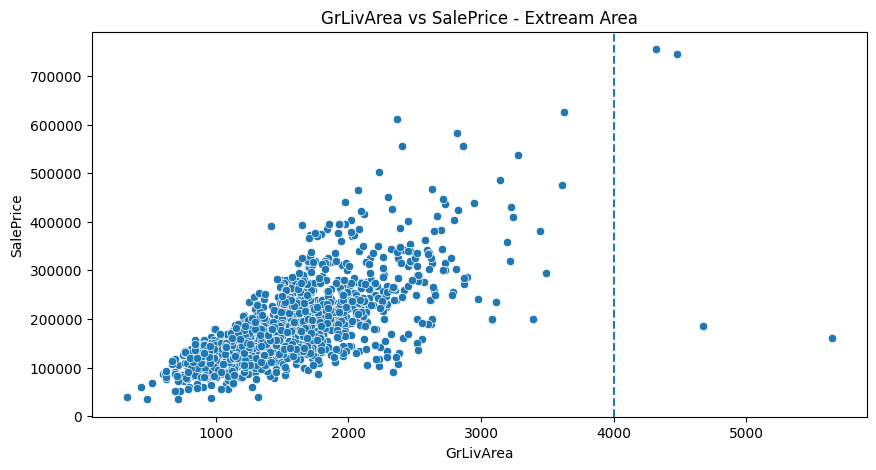

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_clean,
                x='GrLivArea',
                y='SalePrice')
plt.axvline(4000, linestyle='--')
plt.title('GrLivArea vs SalePrice - Extream Area')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

In [ ]:
# removing outlires
df_clean[
    (df_clean['GrLivArea'] > 4000) &
    (df_clean['SalePrice'] < 300000)
][[
    'GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt','Neighborhood', 'Id'
]]

,GrLivArea,SalePrice,OverallQual,YearBuilt,Neighborhood,Id
523,4676,184750,10,2007,Edwards,524
1298,5642,160000,10,2008,Edwards,1299


In [ ]:
df_clean = df_clean[
    ~df_clean['Id'].isin([524, 1299])
].copy()
df_clean.shape

(1458, 81)

In [ ]:
# total sum of features
df_clean['TotalSF'] = (df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF'])
df_clean[['TotalSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].head()

,TotalSF,TotalBsmtSF,1stFlrSF,2ndFlrSF
0,2566,856,856,854
1,2524,1262,1262,0
2,2706,920,920,866
3,2473,756,961,756
4,3343,1145,1145,1053


In [ ]:
# total sum of features
df_clean['TotalBathroom'] = (df_clean['FullBath'] + (0.5 * df_clean['HalfBath']) + 0.5 * df_clean['BsmtFullBath'] + (0.25 * df_clean['BsmtHalfBath']))
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['RemodAge'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalPorchSF'] = (df_clean['OpenPorchSF'] + df_clean['EnclosedPorch'] + df_clean['3SsnPorch'] + df_clean['ScreenPorch'] +df_clean['WoodDeckSF'])
df_clean['HasGarage'] = (df_clean['GarageArea'] > 0).astype(int)
df_clean['HasBasement'] = (df_clean['TotalBsmtSF'] > 0).astype(int)
df_clean['HasFireplace'] = (df_clean['Fireplaces'] > 0).astype(int)
df_clean[['HasGarage', 'HasBasement', 'HasFireplace']].head()
df_clean['HasPool']       = (df_clean['PoolArea'] > 0).astype(int)
df_clean['Has2ndFloor']   = (df_clean['2ndFlrSF'] > 0).astype(int)
df_clean['WasRemodeled']  = (df_clean['YearRemodAdd'] != df_clean['YearBuilt']).astype(int)
print(f"Dataset shape: {df_clean.shape}")


Dataset shape: (1458, 92)


In [ ]:
new_features = ['TotalSF', 'TotalBathroom', 'HouseAge', 'RemodAge', 'TotalPorchSF', 'HasGarage', 'HasBasement', 'HasFireplace', 'HasPool', 'Has2ndFloor', 'WasRemodeled']
# Fix skewed numerical features using log1p
numeric_feats = df_clean.select_dtypes(include=[np.number]).columns
skewed = df_clean[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed = skewed[skewed.abs() > 0.75].sort_values(ascending=False)

print(f"Features with |skewness| > 0.75: {len(skewed)}\n")
print(skewed.head(15).to_string())

Features with |skewness| > 0.75: 26

MiscVal          24.434913
PoolArea         15.932532
HasPool          15.492067
LotArea          12.560986
3SsnPorch        10.286510
LowQualFinSF      8.995688
KitchenAbvGr      4.480268
BsmtFinSF2        4.247550
ScreenPorch       4.114690
BsmtHalfBath      4.095895
EnclosedPorch     3.083987
MasVnrArea        2.693554
OpenPorchSF       2.337421
SalePrice         1.879360
LotFrontage       1.719086


In [ ]:
# Apply log1p to all skewed features
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

skew_index = skewed.index
for feat in skew_index:
    df_clean[feat] = np.log1p(df_clean[feat])

print(f"✅ Applied log1p transform to {len(skew_index)} features")

✅ Applied log1p transform to 26 features


In [ ]:
# Convert some numeric features that are actually categorical
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)
df_clean['YrSold']     = df_clean['YrSold'].astype(str)
df_clean['MoSold']     = df_clean['MoSold'].astype(str)

# One-hot encoding
df_clean = pd.get_dummies(df_clean, drop_first=True)

print(f"✅ After encoding: {df_clean.shape[1]} features")
print(f"Dataset shape: {df_clean.shape}")

✅ After encoding: 393 features
Dataset shape: (1458, 393)


In [ ]:
# Correlation of SalePrice with new features
df_clean[
    new_features + ['SalePrice']
].corr()['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
TotalSF,0.817818
TotalBathroom,0.704565
HasFireplace,0.510253
TotalPorchSF,0.375320
HasGarage,0.322994
HasBasement,0.199626
Has2ndFloor,0.150568
HasPool,0.076516
WasRemodeled,-0.074066


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

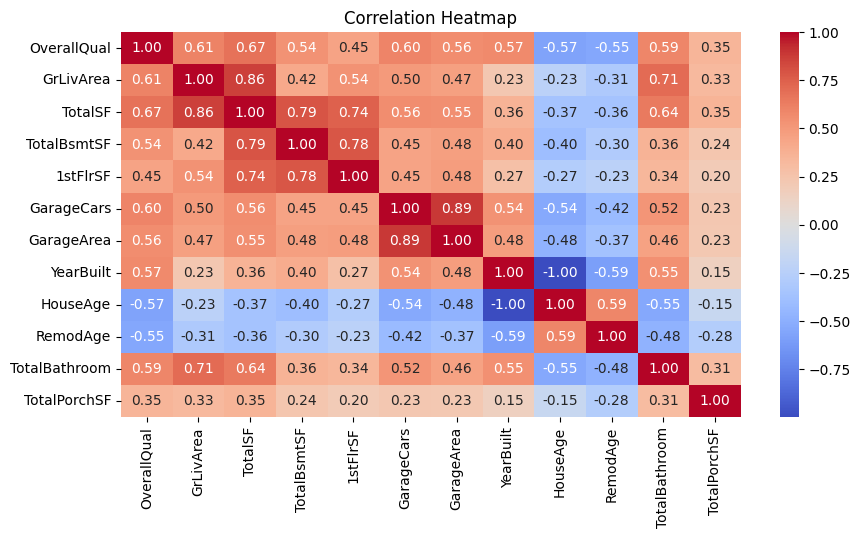

In [ ]:
important_features = ['OverallQual', 'GrLivArea', 'TotalSF', 'TotalBsmtSF', '1stFlrSF', 'GarageCars', 'GarageArea', 'YearBuilt', 'HouseAge', 'RemodAge', 'TotalBathroom', 'TotalPorchSF']

corr_matrix = df_clean[important_features].corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt

In [ ]:
X = df_clean.drop(columns=['SalePrice', 'Id'], axis=1)
y = (df_clean['SalePrice'])

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [ ]:
# Pipeline of Preprocessing
numeric_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])
# Combining Pipline of Numeric & Categoric
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipline, numeric_features),
        ('cat', categorical_pipline, categorical_features)
    ]
)

In [ ]:
from sklearn.linear_model import LinearRegression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'G...
       'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'TotalBathroom',
       'HouseAge', 'RemodAge', 'TotalPorchSF', 'HasGarage', 'HasBasement',
       'HasFireplace', 'HasPool', 'Has2ndFloor', 'WasRemodeled'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
# prediction on log transform SalePrice
y_pred = model.predict(X_test)

In [ ]:
# Regression Metrics for Linear Regression (on actual SalePrice)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

print('Linear Regression Metrics (on actual SalePrice):')
print('Mean Absolute Error:', mae_lr)
print('Mean Squared Error:', mse_lr)
print('Root Mean Squared Error:', rmse_lr)
print('R-squared:', r2_lr * 100 , '%')

Linear Regression Metrics (on actual SalePrice):
Mean Absolute Error: 0.09237695094753391
Mean Squared Error: 0.01674680596148136
Root Mean Squared Error: 0.12940945081979663
R-squared: 90.0657390462203 %


In [ ]:
print('Minimum - max', y_train.min(), y_train.max())
print('Maximum - max:', y_test.min(), y_test.max())


Minimum - max 10.460270761075149 13.534474352733596
Maximum - max: 10.471978128496518 13.02132904585825


In [ ]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

10.460270761075149 13.534474352733596
10.471978128496518 13.02132904585825


# Ridge Model

In [ ]:
# testing on ridge regression
from sklearn.linear_model import Ridge
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

In [ ]:
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

In [ ]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge) # Corrected to use mse_ridge
r2_actual_ridge = r2_score(y_test, y_pred_ridge)

print('Mean Absolute Error:', mae_ridge)
print('Mean Squared Error:', mse_ridge)
print('Root Mean Squared Error:', rmse_ridge)
print('R-squared:', r2_actual_ridge)

Mean Absolute Error: 0.0918961169679471
Mean Squared Error: 0.016485661849426698
Root Mean Squared Error: 0.12839650248128529
R-squared: 0.9022065060139454


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE': [mae_lr, mae_ridge],
    'MSE': [mse_lr, mse_ridge],
    'RMSE': [rmse_lr, rmse_ridge],
    'R-squared': [r2_lr, r2_actual_ridge]
})
results

,Model,MAE,MSE,RMSE,R-squared
0,Linear Regression,0.092377,0.016747,0.129409,0.900657
1,Ridge Regression,0.091896,0.016486,0.128397,0.902207


# Lasso Model

In [ ]:
# testing on lasso regression
from sklearn.linear_model import lasso_path
from sklearn.linear_model import Lasso
lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.001, max_iter=10000))
])

In [ ]:
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
# Since y is already actual SalePrice, no expm1 transformation needed.
y_pred_lasso_actual = y_pred_lasso
y_test_lasso_actual = y_test

In [ ]:
mae_lasso = mean_absolute_error(y_test_lasso_actual, y_pred_lasso_actual)
mse_lasso = mean_squared_error(y_test_lasso_actual, y_pred_lasso_actual)
rmse_lasso = np.sqrt(mse_lasso) # Corrected to use mse_lasso
r2_actual_lasso = r2_score(y_test_lasso_actual, y_pred_lasso_actual)

print('Mean Absolute Error:', mae_lasso)
print('Mean Squared Error:', mse_lasso)
print('Root Mean Squared Error:', rmse_lasso)
print('R-squared:', r2_actual_lasso)

Mean Absolute Error: 0.09174755134894988
Mean Squared Error: 0.016451385326162204
Root Mean Squared Error: 0.1282629538337637
R-squared: 0.9024098354891187


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [mae_lr, mae_ridge, mae_lasso],
    'MSE': [mse_lr, mse_ridge, mse_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R-squared': [r2_lr, r2_actual_ridge, r2_actual_lasso]
})
results

,Model,MAE,MSE,RMSE,R-squared
0,Linear Regression,0.092377,0.016747,0.129409,0.900657
1,Ridge Regression,0.091896,0.016486,0.128397,0.902207
2,Lasso Regression,0.091748,0.016451,0.128263,0.902410


# ElasticNet Model

In [ ]:
from sklearn.linear_model import ElasticNet
elastic_model = Pipeline(
    [('preprocessor', preprocessor),
     ('regressor', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))])
elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)
# Since y is already actual SalePrice, no expm1 transformation needed.
y_pred_elastic_actual = y_pred_elastic
y_test_elastic_actual = y_test

In [ ]:
mae_ele = mean_absolute_error(y_test_elastic_actual, y_pred_elastic_actual)
mse_ele = mean_squared_error(y_test_elastic_actual, y_pred_elastic_actual)
rmse_ele = np.sqrt(mse_ele)
r2_actual_ele = r2_score(y_test_elastic_actual, y_pred_elastic_actual)

print('Mean Absolute Error:', mae_ele)
print('Mean Squared Error:', mse_ele)
print('Root Mean Squared Error:', rmse_ele)
print('R-squared:', r2_actual_ele)

Mean Absolute Error: 0.09185521062017253
Mean Squared Error: 0.016441634870568163
Root Mean Squared Error: 0.1282249385672232
R-squared: 0.9024676755157556


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net Regression'],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_ele],
    'MSE': [mse_lr, mse_ridge, mse_lasso, mse_ele],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_ele],
    'R-squared': [r2_lr, r2_actual_ridge, r2_actual_lasso, r2_actual_ele]
})
# Comparision metrics of all regression
results.sort_values(by='R-squared', ascending=False)

,Model,MAE,MSE,RMSE,R-squared
3,Elastic Net Regression,0.091855,0.016442,0.128225,0.902468
2,Lasso Regression,0.091748,0.016451,0.128263,0.902410
1,Ridge Regression,0.091896,0.016486,0.128397,0.902207
0,Linear Regression,0.092377,0.016747,0.129409,0.900657


# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
ridge_cv = cross_val_score(ridge_model, X_train, y_train, cv=5, scoring='r2')
lasso_cv = cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='r2')
elastic_cv = cross_val_score(elastic_model, X_train, y_train, cv=5, scoring='r2')

cv_results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Lasso Regression', 'Elastic Net Regression'],
    'Mean CV R2': [ridge_cv.mean(), lasso_cv.mean(), elastic_cv.mean()],
    'Std CV R2': [ridge_cv.std(), lasso_cv.std(), elastic_cv.std()]
})
cv_results.sort_values(by='Mean CV R2', ascending=False)

,Model,Mean CV R2,Std CV R2
0,Ridge Regression,0.899766,0.016463
2,Elastic Net Regression,0.899500,0.017441
1,Lasso Regression,0.899215,0.017836


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
#ridge
ridge_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
print(ridge_grid.best_params_)
print(ridge_grid.best_score_ * 100)
# lasso
lasso_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
lasso_grid = GridSearchCV(lasso_model, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)
print(lasso_grid.best_params_)
print(lasso_grid.best_score_ * 100)
#elasticNet
elastic_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(elastic_model, elastic_params, cv=5, scoring='r2', n_jobs=-1)
elastic_grid.fit(X_train, y_train)
print(elastic_grid.best_params_)
print(elastic_grid.best_score_ * 100)

{'regressor__alpha': 0.01}
90.1183213724587
{'regressor__alpha': 0.001}
89.92147396129883
{'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.1}
89.97548283386762


In [ ]:
final_results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Lasso Regression', 'Elastic Net Regression'],
    'Best Score': [ridge_grid.best_score_, lasso_grid.best_score_, elastic_grid.best_score_]
})
final_results.sort_values(by='Best Score', ascending=False)

,Model,Best Score
0,Ridge Regression,0.900845
2,Elastic Net Regression,0.900234
1,Lasso Regression,0.899572


In [ ]:
# best model elasticnet
best_model = ridge_grid.best_estimator_
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r2 * 100 , '%')

Mean Absolute Error: 0.09198393122671004
Mean Squared Error: 0.016604264302854027
Root Mean Squared Error: 0.12885753490911592
R-squared: 90.1502952318503 %


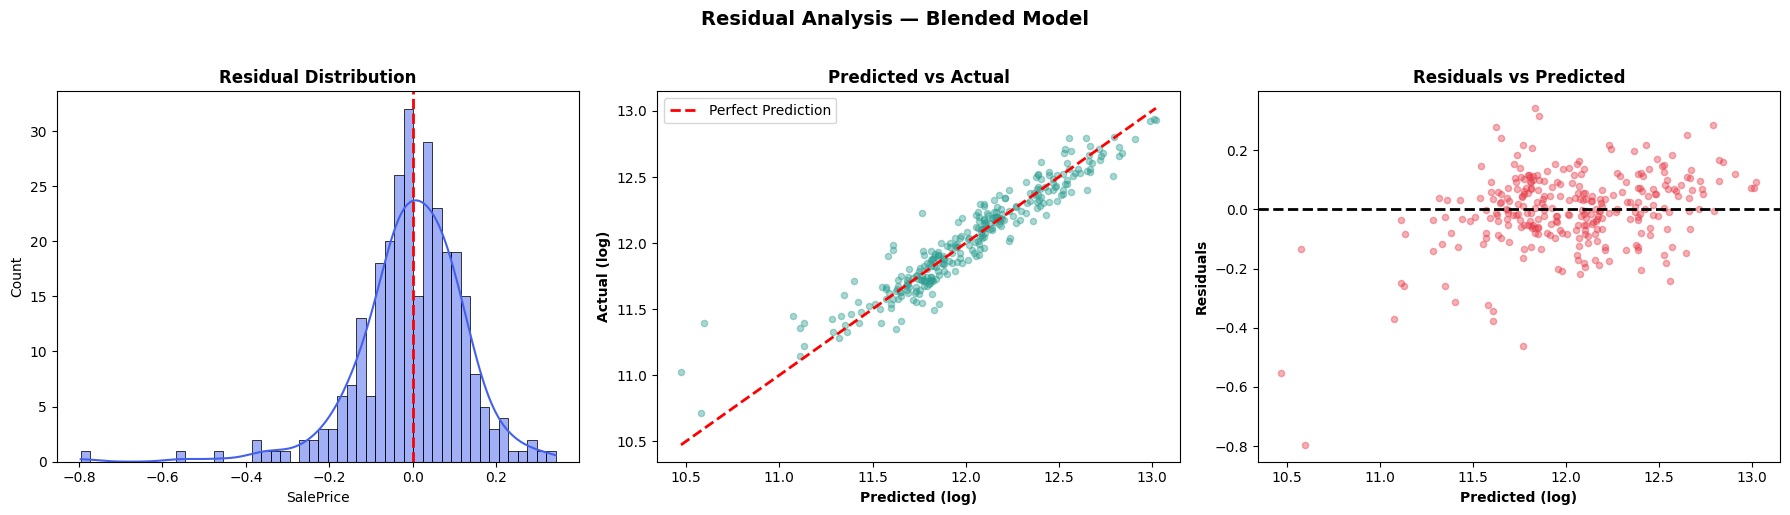


R² Score : 0.901503
MAE      : 0.091984


In [ ]:
# Residuals on training set using blended model
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual distribution
sns.histplot(residuals, kde=True, bins=50, color='#4361ee', ax=axes[0])
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].axvline(0, color='red', ls='--', lw=2)

# Predicted vs Actual
axes[1].scatter(y_test, y_pred, alpha=0.4, c='#2a9d8f', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Predicted (log)', fontweight='bold')
axes[1].set_ylabel('Actual (log)', fontweight='bold')
axes[1].set_title('Predicted vs Actual', fontweight='bold')
axes[1].legend()

# Residuals vs Predicted
axes[2].scatter(y_test, residuals, alpha=0.4, c='#e63946', s=20)
axes[2].axhline(0, color='black', ls='--', lw=2)
axes[2].set_xlabel('Predicted (log)', fontweight='bold')
axes[2].set_ylabel('Residuals', fontweight='bold')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')

plt.suptitle('Residual Analysis — Blended Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nR² Score : {r2:.6f}")
print(f"MAE      : {mae:.6f}")

In [ ]:
print(residuals.min(), residuals.max())

-0.7998554418771437 0.34996612420628814


# Conclusion

Elastic Net Regression achieved the best cross-validation performance among the tested models.

Models compared:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net Regression

Ridge Model was selected as the final model based on cross-validation and hyperparameter tuning.

The final model was evaluated on the unseen test set using:
- MAE
- MSE
- RMSE
- R² Score

Residual analysis and Actual vs Predicted plots were also used to evaluate model performance.